# 7. Integrating equations of motion

All equations of motion are Ordinary Differential Equations. So we'll need to learn how to solve ODEs first. The following is a minimal example with just one variable $x$. 

$$\frac{d x(t)}{dt} = 0.5 x(t)$$ with the initial condition $x(0)=1$.

At every time step, the dynamics of $x$ is propagated forward by $dt$ according to $d x = 0.5 x(t) dt$, and updates $x(t)$ into 

$$x(t+dt) = x(t)+dx = x + 0.5x(t)dt$$

In [5]:
import numpy as np
import matplotlib.pyplot as plt

#YOUR CODE HERE

With some slight changes to the code, we can start **integrating equations of motion** for simple cases like 1D motion with constant velocity. Here's the simplest equation of motion we can write down:

$$\frac{d x(t)}{dt} = v$$ with the initial condition $x(0)=1$m, and $v=1$m/s is a constant.



In [6]:
import numpy as np
import matplotlib.pyplot as plt

#YOUR CODE HERE

A straight line as expected. Next we'll start to compartmentalize this code like we did earlier to make it more managable as it gets more complex in the future. We can introduce a move function to do the updating for us.

This function iteratively updates the particle's position and velocity. 

## Local and Global variables

If you're worried about xpos and xvel appearing both inside the function and outside (when the function is being called), you would not be alone. To understand the behavior of these variables as they are defined and passed around, we need to introduce the distinction between **local** and **global variables**. 

Simply put, everything inside a function is **local**. They are short-lived - created when a function is called can destroyed after the function reaches its end. Everything outside our function is **global**. They remain throughout the lifetime of our entire script as they are being updated. For example, `xpos` is initialized as a global variable. At each timestep, `xpos` is passed on into the `move()` function. The `move()` function then works with its `xpos` local variable, a new variable, and performs `xpos = xpos + xvel * dt`. At the end of the function, the value of the local `xpos` is returned, received outside by the global `xpos`. 

In other words, every variable in inside the `move()` function can be replaced by different names like `xpos` -> `x` or `xvel` -> `vx`. The result will be the same.

In [1]:
def move(x,vx):
    x += (dt*vx)
    return x, vx

Other than local and global variables, there are also names in Python that are reserved for built-in functions like `sum()`. Although we strongly advise against using these to name your variables (e.g. assigning `sum = 10`), this is still allowed in Python. But keep in mind that once you do this, the orginal use of `sum()` as a function will be lost in the current Python session.  

When asked to use a variable with a name that may cause ambiguities between local or global or built-in variables, Python will follow this order to determine which one to take: **local variables > global variables > built-in variables**. Here's an example.

In [1]:
print(sum)

<built-in function sum>


We see that sum is reserved as a name of a built-in function. At any time we are allowed to re-assign the name 'sum' to something else, say an integer quantity

In [2]:
sum=500

In [3]:
print(sum)

500


We can use the same name inside a function. At the time of function definition no command will be executed, so the following block of code will not print anything yet.

In [6]:
def funct(n):
    sum=n+1
    print("sum is ", sum)
    return sum

However, in the next step we call the function and the print statement inside the function will be executed, printing the value associated with sum inside the function.

In [7]:
a=funct(2)
print(a)
print(sum)

sum is  3
3
500


We see that although there are multiple versions of "sum", it is the local variable "sum" that gets printed inside funct().

Another example:

In [8]:
def funct(n):
    print(sum)
    return n+1

In [9]:
funct(2)

500


3

Here there's no local variable `sum`, so the global variable `sum` is printed out.

# Euler's rule, errors, and timestep

So far we got to solve ODEs for a single variable. 

$$\frac{d x(t)}{dt} = v$$ with the initial condition $x(0)=1$m. The velocity $v$ is a constant 1 m/s.

Our most recent code looks like this:

Text(0, 0.5, 'x position')

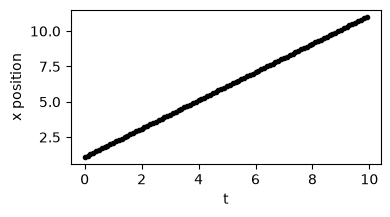

In [10]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1
t_range = np.arange(0,10,dt)

xpos = 1
xvel = 1
xpos_list = []

def move(xpos,xvel):
    xpos += xvel* dt
    return xpos, xvel

for t in t_range:
    xpos, xvel = move(xpos, xvel)
    xpos_list.append(xpos)

plt.figure(figsize=(4,2))    
plt.plot(t_range, xpos_list, 'k.')
plt.xlabel('t')
plt.ylabel('x position')

Now that we can solve ODEs for a single variable, we can easily extend that to **multiple independent variables**.

$$\frac{d x_1(t)}{dt} = v_1$$ 
$$\frac{d x_2(t)}{dt} = v_2$$ 

with some initial conditions. It'll be simply doubling the amount of work and writing another set of equations in the code for $x_2$ so we won't go through it here.

We can now move on to 2nd order differential equations.

$$\frac{d^2 z(t)}{dt^2} = -g$$ 

You may have already guessed where we are going with this – this just Newton's equations for a particle doing free fall. Of course, we haven't solved a 2nd order ODE yet. But we can break it up into two **coupled** 1st order ODEs involving  two **dependent** variables $z$ and $v_z$. 

$$\frac{d z(t)}{dt} = v_z(t)$$ 
$$\frac{d v_z(t)}{dt} = -g$$ 
    

Of course, we two variables to solve for, we need to two initial conditions. Let's set $z(0)=1$ and $v_z(0)=0$. 


In [11]:
#YOUR CODE HERE

## Exercise: Trajectory of projectile under gravity

Next let's try the example of a projectile thrown from the origin, and plot z versus x. With initial conditions 
$x(0)=z(0) = 0$, 
$v_x(0)=3$m/s and 
$v_z=10$m/s.

Discuss how you would approach this and we'll get to work on it after a quick break.

In [12]:
#YOUR CODE HERE

How can we add some bounce?

In [16]:
#YOUR CODE HERE

Add analytical solution to compare with

$$x(t) = v_{0x} t$$
$$z(t) = v_{0z} t - \frac{1}{2}gt^2$$

Careful where we insert this solution. Needs to be before the numerical solve.

In [13]:
#YOUR CODE HERE

Anything obviously wrong about the trajectory? The particle is gaining height – energy is not conserved! This is due to the method we used to integrate out the equations of motion. Using $x = x + v_x dt$ to integrate out $dx/dt = v_x$ is called **Euler's rule**. 

(Discussion on Euler's rule, Taylor's expansion, $O(dt^2)$ **local error** and $O(dt)$ **global error**.)

Two things to do: 
- Find a better dt. Or even better, find a strategy to determine what dt should be.
- Check energy convervation numerically

Let's discuss the choice the timestep $dt$ first.

<div class="span alert alert-success">

## Choosing step size according to the physical problem
    
- Step too big = larger error
- Step too small = computational waste
    

The size of the timestep should be small. But what is small? Compared to what? 

The timestep $\Delta t$ should be much smaller compared to the **characteristic timescale $\bf\tau$** of the problem, $\Delta t << \tau$. What is this timescale then? 

**Exmaple 1.** For throwing a ball in the air, $\tau$ would be the time the ball travels in the air before hitting the ground. 

**Exmaple 2.** For earth revolving around the sun, $\tau$ is on the order of a year. 

**Exmaple 3.** For simulating molecules floating around not reacting with each other, $\tau$ is on the order of phonon vibration periods, which is picoseconds = $10^{-9}$s.
    
A rule of thumb is to use $\Delta t = 0.01 \tau$.

</div>

In our case, how long before the first bounce?  Multiply that by 0.01 and see if the results are better.

# Energy conservation & subplots


To see the violation of energy conservation more clearly, let's monitor the energies througout the simulation.

In [19]:
mass=0.1

def KineticE(v):
    return 0.5*mass*v**2

def PotentialE(zpos):
    return mass*g*zpos

KEn=[]
PEn=[]
TEn=[]

KE = KineticE( np.sqrt(xvel**2 + zvel**2) )
PE = PotentialE( zpos)
KEn.append(KE)
PEn.append(PE)
TEn.append(KE+PE )

Below is our final version of this project. Here we introduce **subplots** so that we can plot two figures side by side. This is a more advanced way of creating plots, where we can control multiple plots using their axes. In the example below they are labeled ax.

In [14]:
#YOUR CODE HERE

## Animation
As a bonus of finishing the Euler's rule project, you can remove the plotting section and replace it with the following code. You'll be able to generate an animation of the bouncing particle. (A brief discussion of the animation function.)

Overall we need three parts shown below. The first block initiates a figure window for the animation, with proper boundaries and plot styles determined. 

The second animate() block tells the program how to update each time and move forward in time.

Finally, the third part realizes the animation, controlled by some parameters. The first argument needs to be the figure window you initiate, e.g. "fig" here. The second argument is the function that updates the animation, e.g. "animate" here. The argument "interval" is the time it takes for each frame.

&nbsp;  
&nbsp;
&nbsp;

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.animation as ani
from IPython.display import HTML

plt.close('all')

fig, axes = plt.subplots()

axes.set_xlim(0, 30)
axes.set_ylim(0, 10)

plot1, = axes.plot([], [], 'go')

def animate(i):
    plot1.set_data([xpos_list[i]], [zpos_list[i]])
    return plot1,

frame_skip = 10

anim = ani.FuncAnimation(
    fig,
    animate,
    frames=range(0, len(t_range), frame_skip),
    interval=20,
    repeat=True,
    blit=True
)

plt.close(fig)
HTML(anim.to_jshtml())

## Exercise: animate the particle's trajectory and energy plots simultanesouly

Hint: to access a range in a list, you can use list_name[start:end]